In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
INVESTIGASI HASIL UNDUHAN WAVEFORM
- Jumlah file, ukuran, distribusi stasiun
- Komponen yang tersedia (Z, N, E)
- Kualitas sinyal (SNR) untuk sampel
- Deteksi file corrupt
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from obspy import read, UTCDateTime
from obspy.signal.trigger import recursive_sta_lta
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_juli_hybrid_katalog_2026"
OUTPUT_DIR = "investigasi_waveform"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# Parameter untuk sampel SNR
SAMPLE_SIZE = 500  # ambil 500 file acak untuk analisis SNR
STA_WIN = 1.0
LTA_WIN = 10.0
TRIGGER_THRESHOLD = 3.5
SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0

# =============================================
# 2. BACA FILE .mseed
# =============================================

print("="*70)
print("📊 INVESTIGASI HASIL UNDUHAN WAVEFORM")
print("="*70)

print(f"\n📂 Membaca direktori: {WAVEFORM_DIR}")
files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
# Filter file ._ (macOS metadata)
files = [f for f in files if not f.name.startswith('._')]
print(f"✅ Total file .mseed valid: {len(files):,}")

if len(files) == 0:
    print("❌ Tidak ada file .mseed ditemukan!")
    exit()

# =============================================
# 3. EKSTRAK METADATA DARI NAMA FILE
# =============================================

print("\n📊 Ekstrak metadata dari nama file...")

def parse_filename(filename):
    """Ekstrak network, station, dan event_id dari nama file."""
    stem = filename.stem
    parts = stem.split('_')
    
    if len(parts) >= 3:
        network = parts[0]
        station = parts[1]
        event_id = '_'.join(parts[2:])
    else:
        network = 'UNK'
        station = 'UNK'
        event_id = stem
    
    return {
        'file': filename.name,
        'network': network,
        'station': station,
        'event_id': event_id,
        'size_kb': filename.stat().st_size / 1024
    }

metadata = []
for f in files:
    meta = parse_filename(f)
    metadata.append(meta)

df_meta = pd.DataFrame(metadata)
print(f"✅ Metadata diekstrak dari {len(df_meta):,} file")

# =============================================
# 4. STATISTIK DASAR
# =============================================

print("\n" + "="*70)
print("📊 STATISTIK DASAR")
print("="*70)

print(f"Total file: {len(df_meta):,}")
print(f"Total storage: {df_meta['size_kb'].sum() / (1024*1024):.2f} GB")
print(f"Rata-rata ukuran: {df_meta['size_kb'].mean():.1f} KB")
print(f"Median ukuran: {df_meta['size_kb'].median():.1f} KB")
print(f"Min ukuran: {df_meta['size_kb'].min():.1f} KB")
print(f"Max ukuran: {df_meta['size_kb'].max():.1f} KB")

# =============================================
# 5. DISTRIBUSI STASIUN
# =============================================

print("\n📡 20 STASIUN TERBANYAK:")
station_counts = df_meta['station'].value_counts()
for sta, count in station_counts.head(20).items():
    pct = count / len(df_meta) * 100
    print(f"  {sta}: {count:,} ({pct:.1f}%)")

print(f"\n📡 Total stasiun unik: {df_meta['station'].nunique():,}")

# =============================================
# 6. DISTRIBUSI JARINGAN
# =============================================

print("\n📡 10 JARINGAN TERBANYAK:")
network_counts = df_meta['network'].value_counts()
for net, count in network_counts.head(10).items():
    pct = count / len(df_meta) * 100
    print(f"  {net}: {count:,} ({pct:.1f}%)")

print(f"\n📡 Total jaringan unik: {df_meta['network'].nunique():,}")

# =============================================
# 7. CEK KOMPONEN (Z, N, E) UNTUK SAMPEL
# =============================================

print("\n📊 CEK KOMPONEN (Z, N, E) - 500 file sampel...")

def check_components(file_path):
    """Cek komponen yang tersedia dalam file .mseed."""
    try:
        st = read(str(file_path))
        channels = [tr.stats.channel for tr in st]
        has_z = any(ch.endswith('Z') for ch in channels)
        has_n = any(ch.endswith('N') for ch in channels)
        has_e = any(ch.endswith('E') for ch in channels)
        return {
            'has_z': has_z,
            'has_n': has_n,
            'has_e': has_e,
            'channels': channels,
            'n_traces': len(st)
        }
    except Exception as e:
        return {
            'has_z': False,
            'has_n': False,
            'has_e': False,
            'channels': [],
            'n_traces': 0,
            'error': str(e)
        }

# Ambil 500 file acak
sample_files = np.random.choice(files, min(SAMPLE_SIZE, len(files)), replace=False)
component_data = []

for f in tqdm(sample_files, desc="Cek komponen"):
    comp = check_components(f)
    comp['file'] = f.name
    component_data.append(comp)

df_comp = pd.DataFrame(component_data)

print(f"\n✅ File dengan komponen Z: {df_comp['has_z'].sum()}/{len(df_comp)} ({df_comp['has_z'].sum()/len(df_comp)*100:.1f}%)")
print(f"✅ File dengan komponen N: {df_comp['has_n'].sum()}/{len(df_comp)} ({df_comp['has_n'].sum()/len(df_comp)*100:.1f}%)")
print(f"✅ File dengan komponen E: {df_comp['has_e'].sum()}/{len(df_comp)} ({df_comp['has_e'].sum()/len(df_comp)*100:.1f}%)")

# File tanpa Z
no_z = df_comp[~df_comp['has_z']]
if len(no_z) > 0:
    print(f"\n⚠️ {len(no_z)} file TANPA komponen Z (contoh):")
    for _, row in no_z.head(5).iterrows():
        print(f"  - {row['file']} (channels: {row['channels']})")

# File dengan 3 komponen
three_comp = df_comp[(df_comp['has_z']) & (df_comp['has_n']) & (df_comp['has_e'])]
print(f"\n✅ File dengan 3 komponen (Z, N, E): {len(three_comp)}/{len(df_comp)} ({len(three_comp)/len(df_comp)*100:.1f}%)")

# =============================================
# 8. CEK FILE CORRUPT / TERLALU KECIL
# =============================================

print("\n📊 CEK FILE CORRUPT / TERLALU KECIL...")

# File dengan ukuran < 1 KB dianggap corrupt
corrupt_files = df_meta[df_meta['size_kb'] < 1]
print(f"✅ File dengan ukuran < 1 KB (corrupt): {len(corrupt_files):,} ({len(corrupt_files)/len(df_meta)*100:.2f}%)")

# File dengan ukuran < 10 KB (mungkin tidak lengkap)
small_files = df_meta[(df_meta['size_kb'] >= 1) & (df_meta['size_kb'] < 10)]
print(f"✅ File dengan ukuran 1-10 KB (mungkin tidak lengkap): {len(small_files):,} ({len(small_files)/len(df_meta)*100:.2f}%)")

# =============================================
# 9. SIMPAN HASIL
# =============================================

df_meta.to_csv(f"{OUTPUT_DIR}/file_metadata.csv", index=False)
df_comp.to_csv(f"{OUTPUT_DIR}/component_analysis.csv", index=False)
print(f"\n✅ Metadata tersimpan: {OUTPUT_DIR}/file_metadata.csv")
print(f"✅ Komponen tersimpan: {OUTPUT_DIR}/component_analysis.csv")

# =============================================
# 10. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊 RINGKASAN INVESTIGASI")
print("="*70)
print(f"Total file: {len(df_meta):,}")
print(f"Total storage: {df_meta['size_kb'].sum() / (1024*1024):.2f} GB")
print(f"File dengan 3 komponen: {len(three_comp)}/{len(df_comp)} ({len(three_comp)/len(df_comp)*100:.1f}%)")
print(f"File corrupt (<1 KB): {len(corrupt_files):,}")
print(f"Stasiun terbanyak: {station_counts.index[0]} ({station_counts.iloc[0]:,} file)")
print(f"Jaringan terbanyak: {network_counts.index[0]} ({network_counts.iloc[0]:,} file)")
print("="*70)

📊 INVESTIGASI HASIL UNDUHAN WAVEFORM

📂 Membaca direktori: /Volumes/Extreme SSD/unduhan_juli_hybrid_katalog_2026
✅ Total file .mseed valid: 18,804

📊 Ekstrak metadata dari nama file...
✅ Metadata diekstrak dari 18,804 file

📊 STATISTIK DASAR
Total file: 18,804
Total storage: 0.42 GB
Rata-rata ukuran: 23.5 KB
Median ukuran: 19.5 KB
Min ukuran: 0.5 KB
Max ukuran: 207.0 KB

📡 20 STASIUN TERBANYAK:
  TNTI: 4,076 (21.7%)
  PMG: 2,599 (13.8%)
  GENI: 1,367 (7.3%)
  MNAI: 1,182 (6.3%)
  GSI: 1,039 (5.5%)
  BNDI: 877 (4.7%)
  LHMI: 858 (4.6%)
  SAUI: 841 (4.5%)
  FAKI: 778 (4.1%)
  LUWI: 672 (3.6%)
  PLAI: 580 (3.1%)
  TOLI2: 512 (2.7%)
  JAGI: 475 (2.5%)
  BBJI: 452 (2.4%)
  SANI: 443 (2.4%)
  SOEI: 301 (1.6%)
  MMRI: 284 (1.5%)
  CISI: 281 (1.5%)
  BKNI: 266 (1.4%)
  BB02: 239 (1.3%)

📡 Total stasiun unik: 32

📡 10 JARINGAN TERBANYAK:
  GE: 18,462 (98.2%)
  7G: 341 (1.8%)
  XN: 1 (0.0%)

📡 Total jaringan unik: 3

📊 CEK KOMPONEN (Z, N, E) - 500 file sampel...


Cek komponen: 100%|██████████| 500/500 [00:01<00:00, 423.63it/s]


✅ File dengan komponen Z: 499/500 (99.8%)
✅ File dengan komponen N: 426/500 (85.2%)
✅ File dengan komponen E: 427/500 (85.4%)

⚠️ 1 file TANPA komponen Z (contoh):
  - GE_TNTI_20150705_013608.mseed (channels: ['BHE'])

✅ File dengan 3 komponen (Z, N, E): 426/500 (85.2%)

📊 CEK FILE CORRUPT / TERLALU KECIL...
✅ File dengan ukuran < 1 KB (corrupt): 1 (0.01%)
✅ File dengan ukuran 1-10 KB (mungkin tidak lengkap): 384 (2.04%)

✅ Metadata tersimpan: investigasi_waveform/file_metadata.csv
✅ Komponen tersimpan: investigasi_waveform/component_analysis.csv

📊 RINGKASAN INVESTIGASI
Total file: 18,804
Total storage: 0.42 GB
File dengan 3 komponen: 426/500 (85.2%)
File corrupt (<1 KB): 1
Stasiun terbanyak: TNTI (4,076 file)
Jaringan terbanyak: GE (18,462 file)


In [4]:
import json
import random

def cek_kualitas_json(filepath):
    print(f"⏳ Sedang membaca file JSON... (Mohon tunggu sebentar)")
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        total_data = len(data)
        print(f"✅ Berhasil! Terdapat {total_data} record di dalam JSON.\n")
        
        # Ambil 1 kunci (event) secara acak
        random_key = random.choice(list(data.keys()))
        sample = data[random_key]
        
        # Karena array sinyal panjangnya 700, kita potong agar rapi di layar
        for comp in ['Z', 'N', 'E', 'Z_noise', 'N_noise', 'E_noise']:
            if comp in sample and isinstance(sample[comp], list):
                arr = sample[comp]
                if len(arr) >= 6:
                    # Tampilkan 3 angka pertama dan 3 angka terakhir
                    sample[comp] = f"[ {arr[0]:.4f}, {arr[1]:.4f}, {arr[2]:.4f}, ... , {arr[-3]:.4f}, {arr[-2]:.4f}, {arr[-1]:.4f} ] (Panjang array: {len(arr)})"
                
        print("="*60)
        print(f"SAMPEL DATA ACAK (ID: {random_key})")
        print("="*60)
        print(json.dumps(sample, indent=4))
        
    except Exception as e:
        print(f"❌ Terjadi kesalahan: {e}")

if __name__ == "__main__":
    # Ganti path ini jika lokasinya berbeda
    filepath = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_3c_4.json'
    cek_kualitas_json(filepath)

⏳ Sedang membaca file JSON... (Mohon tunggu sebentar)
✅ Berhasil! Terdapat 8456 record di dalam JSON.

SAMPEL DATA ACAK (ID: GE_GENI_20160629_083637)
{
    "type": "se",
    "Z": "[ -0.0051, -0.0053, -0.0056, ... , 0.0294, 0.0290, 0.0286 ] (Panjang array: 700)",
    "N": "[ -0.0698, -0.0710, -0.0723, ... , -0.1025, -0.1008, -0.0991 ] (Panjang array: 700)",
    "E": "[ -0.0853, -0.0868, -0.0882, ... , -0.2643, -0.2596, -0.2549 ] (Panjang array: 700)",
    "Z_noise": "[ -0.0344, -0.0348, -0.0353, ... , -0.0539, -0.0530, -0.0522 ] (Panjang array: 700)",
    "N_noise": "[ 0.1053, 0.1073, 0.1093, ... , -0.0015, -0.0014, -0.0013 ] (Panjang array: 700)",
    "E_noise": "[ 0.0766, 0.0787, 0.0809, ... , -0.1508, -0.1484, -0.1460 ] (Panjang array: 700)",
    "metadata": {
        "network": "GE",
        "station": "GENI",
        "p_arrival": "2016-06-29T08:36:15.069536Z",
        "file": "GE_GENI_20160629_083637.mseed",
        "origin_time": "2016-06-29T08:36:37.490000+00:00",
        "latitu

In [8]:
import json

def audit_json_quality(filepath):
    print(f"🔍 Memulai audit integritas untuk: {filepath}")
    print("Mohon tunggu, sedang memindai seluruh record...")
    
    total_records = 0
    records_with_padding = 0
    records_with_nan = 0
    
    try:
        with open(filepath, 'r') as f:
            # Membaca sebagai file object untuk iterasi jika memungkinkan
            # Tapi karena ini JSON, kita load seluruhnya (pastikan RAM cukup)
            data = json.load(f)
            
        total_records = len(data)
        
        for key, record in data.items():
            # Cek Z_noise (biasanya paling rentan zero-padding)
            z_noise = record.get('Z_noise', [])
            
            # 1. Cek Zero-Padding (cek apakah 10 titik terakhir adalah nol semua)
            # Ini indikasi kuat adanya padding yang tidak alami
            if all(val == 0.0 for val in z_noise[-10:]):
                records_with_padding += 1
            
            # 2. Cek NaN/Inf (Integritas matematis)
            if any(val != val for val in z_noise): # val != val adalah trik cek NaN
                records_with_nan += 1
                
        print("="*60)
        print("LAPORAN HASIL AUDIT")
        print("="*60)
        print(f"Total Record          : {total_records}")
        print(f"Record Cacat (Padding): {records_with_padding} ({records_with_padding/total_records*100:.2f}%)")
        print(f"Record Cacat (NaN)    : {records_with_nan}")
        print("="*60)
        
        if records_with_padding > 0:
            print("⚠️ REKOMENDASI: Sebaiknya jalankan ulang ekstraksi dengan filter padding.")
        else:
            print("✅ DATA AMAN: Seluruh record tidak mengandung padding buatan.")

    except Exception as e:
        print(f"❌ Terjadi kesalahan saat audit: {e}")

if __name__ == "__main__":
    # Ganti dengan path file JSON yang ingin diaudit
    filepath = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_3c_4.json'
    audit_json_quality(filepath)

🔍 Memulai audit integritas untuk: /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_3c_4.json
Mohon tunggu, sedang memindai seluruh record...
LAPORAN HASIL AUDIT
Total Record          : 8456
Record Cacat (Padding): 1233 (14.58%)
Record Cacat (NaN)    : 0
⚠️ REKOMENDASI: Sebaiknya jalankan ulang ekstraksi dengan filter padding.


In [10]:
import json
import os

def clean_json_dataset(input_filepath, output_filepath):
    print(f"🧹 Memulai pembersihan data...")
    print(f"📂 Input : {input_filepath}")
    
    with open(input_filepath, 'r') as f:
        data = json.load(f)
        
    total_records = len(data)
    cleaned_data = {}
    records_removed = 0
    
    print(f"⏳ Sedang menyaring {total_records} record...")
    
    for key, record in data.items():
        z_noise = record.get('Z_noise', [])
        
        # Syarat bersih: 10 titik terakhir tidak boleh nol semua
        # Kita menggunakan toleransi kecil (misal < 1e-6) daripada 0.0 tepat
        is_padded = all(abs(val) < 1e-6 for val in z_noise[-10:])
        
        if is_padded:
            records_removed += 1
        else:
            cleaned_data[key] = record
            
    print("="*60)
    print("HASIL PEMBERSIHAN DATA")
    print("="*60)
    print(f"Total Record Awal  : {total_records}")
    print(f"Record Dibuang     : {records_removed} ({records_removed/total_records*100:.2f}%)")
    print(f"Total Record Bersih: {len(cleaned_data)}")
    print("="*60)
    
    with open(output_filepath, 'w') as f:
        json.dump(cleaned_data, f, indent=2)
    print(f"✅ Data bersih tersimpan di: {output_filepath}")

if __name__ == "__main__":
    # Path file yang akan dibersihkan
    input_file = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_3c_4.json'
    output_file = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_3c_4_CLEAN.json'
    
    clean_json_dataset(input_file, output_file)


🧹 Memulai pembersihan data...
📂 Input : /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_3c_4.json
⏳ Sedang menyaring 8456 record...
HASIL PEMBERSIHAN DATA
Total Record Awal  : 8456
Record Dibuang     : 1236 (14.62%)
Total Record Bersih: 7220
✅ Data bersih tersimpan di: /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_3c_4_CLEAN.json


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Total data: 12754


  0%|          | 0/12754 [00:00<?, ?it/s]

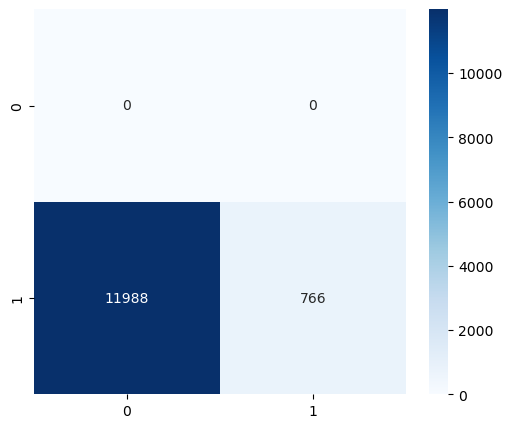

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.06      0.11     12754

    accuracy                           0.06     12754
   macro avg       0.50      0.03      0.06     12754
weighted avg       1.00      0.06      0.11     12754



/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [1]:
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # Ubah ke notebook

# 1. Load Interpreter
model_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/MCU-Quake 5-20/lite_model.tflite'
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def model_inference_tflite(waveform_data):
    # Debug: Print shape untuk memastikan model menerima input yang benar
    input_data = np.array(waveform_data, dtype=np.float32).reshape(1, 700, 1)
    
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data[0][0] 

# 2. Load File JSON
json_path = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4.json'
with open(json_path, 'r') as f:
    data = json.load(f)

y_true = []
y_pred = []

# 3. Running loop dengan print sederhana untuk debug
print(f"Total data: {len(data)}")

# Kita tes 5 record pertama dulu agar tidak hang
keys = list(data.keys())
for i, event_id in enumerate(tqdm(keys)):
    record = data[event_id]
    label_asli = 1 if record.get('type') == 'se' else 0
    
    try:
        prob = model_inference_tflite(record['Z'])
        prediksi = 1 if prob > 0.5 else 0
        
        y_true.append(label_asli)
        y_pred.append(prediksi)
    except Exception as e:
        print(f"Error pada event {event_id}: {e}")
        break

# 4. Visualisasi
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()
print(classification_report(y_true, y_pred))